### Load data in using the same logic as data exploration

In [68]:
import os
import glob
import pandas as pd
import numpy as np

%matplotlib inline

DATA_ROOT = os.path.join("data", "ami")

AUDIO_DIR = os.path.join(DATA_ROOT, "audio")
SUMMARY_DIR = os.path.join(DATA_ROOT, "summary")
TRANSCRIPT_DIR = os.path.join(DATA_ROOT, "transcript")

In [69]:
def parse_transcript(filepath):

    utterances = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            parts = line.strip().split("\t")

            if len(parts) != 4:
                print('Transcript line parts mismatch')
                continue

            speaker, start_time, text, section = parts

            utterances.append({
                "speaker": speaker,
                "start_time": float(start_time),
                "text": text,
                "section": section
            })

    utterance_df = pd.DataFrame(utterances)

    if len(utterance_df) == 0:
        return "", utterance_df

    # Build full transcript text
    transcript_text = " ".join(utterance_df["text"].tolist())

    return transcript_text, utterance_df

In [70]:
def load_transcripts(transcript_dir):

    records = []

    for split in ["train", "valid", "test"]:

        split_dir = os.path.join(transcript_dir, split)

        for filepath in glob.glob(os.path.join(split_dir, "*.txt")):

            meeting_id = os.path.basename(filepath).replace(".txt", "")

            transcript_text, utterance_df = parse_transcript(filepath)

            records.append({
                "meeting_id": meeting_id,
                "split": split,
                "transcript": transcript_text,
                "num_utterances": len(utterance_df),
                "num_speakers": utterance_df["speaker"].nunique()
            })

    return pd.DataFrame(records)

In [71]:
def load_summaries(summary_dir):

    summaries = {}

    for filepath in glob.glob(os.path.join(summary_dir, "*.txt")):
        meeting_id = os.path.basename(filepath).replace(".txt", "")

        with open(filepath, "r", encoding="utf-8") as f:
            summaries[meeting_id] = f.read()

    return summaries

In [72]:
def load_audio_paths(audio_dir):

    audio_records = []

    for meeting in os.listdir(audio_dir):

        meeting_audio_dir = os.path.join(audio_dir, meeting, "audio")

        if not os.path.isdir(meeting_audio_dir):
            continue

        headset = None
        lapel = None

        for file in os.listdir(meeting_audio_dir):

            if "Headset" in file:
                headset = os.path.join(meeting_audio_dir, file)

            if "Lapel" in file:
                lapel = os.path.join(meeting_audio_dir, file)

        audio_records.append({
            "meeting_id": meeting,
            "audio_headset": headset,
            "audio_lapel": lapel
        })

    return pd.DataFrame(audio_records)

In [73]:
def build_dataset():
    transcripts_df = load_transcripts(TRANSCRIPT_DIR)

    summaries = load_summaries(SUMMARY_DIR)

    audio_df = load_audio_paths(AUDIO_DIR)

    # attach summaries
    transcripts_df["summary"] = transcripts_df["meeting_id"].map(summaries)

    # merge audio paths
    df = transcripts_df.merge(audio_df, on="meeting_id", how="left")
    
    # get the transcript and summary lengths in words, and the ratio of summary length to transcript length
    # we also tested character counts, but the ratios were very similar to word counts
    df['transcript_length'] = df['transcript'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['summary_length'] = df['summary'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['ratio_summary_to_transcript'] = df.apply(lambda row: row['summary_length'] / row['transcript_length'] if row['transcript_length'] > 0 else 0, axis=1)

    return df

In [74]:
df = build_dataset()

print(df.shape)
print(df.head())

(137, 11)
  meeting_id  split                                         transcript  \
0    ES2002a  train  Okay . Right . Um well this is the kick-off me...   
1    ES2002b  train  Is that alright now ? Okay . Sorry ? Okay , ev...   
2    ES2002c  train  'S to do now is to decide how to fulfil what y...   
3    ES2002d  train  Okay we all all set ? Right . Well this is the...   
4    ES2005a  train  Uh , making a profit of fifty million Euros . ...   

   num_utterances  num_speakers  \
0             332             4   
1             691             4   
2             634             4   
3             854             4   
4              93             4   

                                             summary  \
0  The project manager introduced the upcoming pr...   
1  The project manager briefed the team on some n...   
2  The project manager recapped the decisions mad...   
3  The project manager recapped the decisions mad...   
4  The group discussed their initial ideas about ...  

### Making a custom Dataset class to handling chunking of transcripts, maps each chunk to the summary, and tokenizes the inputs / target summary.

I referenced https://blog.roboflow.com/pytorch-custom-dataset/ for this part of the code.

In [75]:
import torch

class MeetingSummarizationDataset(torch.utils.data.Dataset):
    """
    Each meeting transcript is split into overlapping chunks so that
    it fits within the model's maximum input length.
    This allows training on long transcripts that would exceed token limits.
    """

    def __init__(
        self,
        df,
        tokenizer,
        max_input_tokens=512,
        max_target_tokens=128,
        stride=128
    ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_input_tokens = max_input_tokens
        self.max_target_tokens = max_target_tokens
        self.stride = stride

        # This will store all (meeting, chunk) pairs
        self.samples = []

        self.split_transcripts_to_chunks()

    def _chunk_text(self, text):
        """
        Splits a long transcript into overlapping token chunks.
        Overlap helps preserve context across chunk boundaries
        """
        tokens = self.tokenizer.encode(text, add_special_tokens=False)

        chunks = []
        start = 0

        while start < len(tokens):
            end = start + self.max_input_tokens
            chunk_tokens = tokens[start:end]
            chunks.append(chunk_tokens)

            # Move forward with overlap
            start += (self.max_input_tokens - self.stride)

        return chunks

    def split_transcripts_to_chunks(self):
        """
        Each chunk of each meeting becomes a separate training example so we can treat long documents as many smaller training samples.
        """
        for idx, row in self.df.iterrows():

            # Skip rows without summaries
            if not isinstance(row["summary"], str):
                continue

            chunks = self._chunk_text(row["transcript"])

            for chunk_tokens in chunks:
                self.samples.append({
                    "df_idx": idx,
                    "chunk_tokens": chunk_tokens
                })

    def __len__(self):
        """Total number of chunks across all meetings."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Returns one training example: (input chunk, summary)
        """
        sample = self.samples[idx]
        row = self.df.iloc[sample["df_idx"]]

        # Convert token chunk back to text for standard tokenizer processing
        input_text = self.tokenizer.decode(
            sample["chunk_tokens"],
            skip_special_tokens=True
        )

        # Tokenize input (transcript chunk)
        model_inputs = self.tokenizer(
            input_text,
            max_length=self.max_input_tokens,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Tokenize target (full summary)
        target = self.tokenizer(
            row["summary"],
            max_length=self.max_target_tokens,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Remove batch dimension added by tokenizer
        # TODO This seems to work but I'm a bit confused by that batching. Seems to me this will run really slow since we aren't using any batching, but idk how to fix that since __getitem__ returns just one
        input_ids = model_inputs["input_ids"].squeeze(0)
        attention_mask = model_inputs["attention_mask"].squeeze(0)
        labels = target["input_ids"].squeeze(0)

        # Replace padding tokens in labels with -100 so they are ignored in loss
        
        # TODO is this right???
        
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,

            # including the meeting ID so we can later use it to map eval info
            "meeting_id": row["meeting_id"]
        }

In [76]:
from transformers import AutoTokenizer

model_name = "facebook/bart-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

c:\Users\andre\anaconda3\envs\Group4\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]

# TODO remove after testing!

# USING A SUBSET OF DATA TO DEBUG THE MODEL
train_subset = set(train_df["meeting_id"].unique()[:3])
train_df = train_df[train_df["meeting_id"].isin(train_subset)]

valid_subset = set(train_df["meeting_id"].unique()[:3])
valid_df = train_df[train_df["meeting_id"].isin(valid_subset)]

train_dataset = MeetingSummarizationDataset(train_df, tokenizer)
valid_dataset = MeetingSummarizationDataset(valid_df, tokenizer)

print(len(train_dataset))
print(len(valid_dataset))


In [78]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

In [79]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)     # (batch_size, 512)
print(batch["labels"].shape)        # (batch_size, 128)

torch.Size([4, 512])
torch.Size([4, 128])


In [80]:
print(len(train_dataset))

sample = train_dataset[0]

print(tokenizer.decode(sample["input_ids"]))
print("\n--- TARGET ---\n")
print(tokenizer.decode(
    [t for t in sample["labels"] if t != -100]
))

58
<s>Okay. Right. Um well this is the kick-off meeting for our our project. Um and um this is just what we're gonna be doing over the next twenty five minutes. Mm-hmm. Um so first of all, just to kind of make sure that we all know each other, I'm Laura and I'm the project manager. Do you want to introduce yourself again? Great. Hi, I'm David and I'm supposed to be an industrial designer. Okay. And I'm Andrew and I'm uh our marketing expert. Um I'm Craig and I'm User Interface. Great. Okay. Um so we're designing a new remote control and um Oh I have to record who's here actually. So that's David, Andrew and Craig, isn't it? And you all arrived on time. Um yeah so des uh design a new remote control. Um, as you can see it's supposed to be original, trendy and user friendly. Um so that's kind of our our brief, as it were. Um and so there are three different stages to the design. Um I'm not really sure what what you guys have already received um in your emails. What did you get? Um, I just

In [81]:
from transformers import (
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq
)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [82]:
import evaluate

rouge = evaluate.load("rouge")


def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Replace -100 with pad token id so we can decode
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    return {
        "rouge1": scores["rouge1"],
        "rouge2": scores["rouge2"],
        "rougeL": scores["rougeL"]
    }

In [83]:
from transformers import Seq2SeqTrainingArguments
import torch

training_args = Seq2SeqTrainingArguments(
    output_dir="./results",

    # Core training
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,

    # Evaluation
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,

    # Logging
    logging_steps=50,
    logging_dir="./logs",
    report_to="tensorboard",

    # Seq2Seq-specific (THIS is where generation belongs)
    predict_with_generate=True,
    generation_max_length=128,
    generation_num_beams=4,

    # Performance
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,

    seed=42
)

c:\Users\andre\anaconda3\envs\Group4\lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [84]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

c:\Users\andre\anaconda3\envs\Group4\lib\site-packages\accelerate\accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
100%|██████████| 594/594 [51:23<00:00,  5.19s/it]


In [85]:
from collections import defaultdict
import evaluate

rouge = evaluate.load("rouge")

def generate_meeting_summaries(model, dataset, tokenizer, device):
    model.eval()
    model.to(device)

    meeting_chunks = defaultdict(list)

    # Group chunks
    for i in range(len(dataset)):
        item = dataset[i]
        meeting_chunks[item["meeting_id"]].append(item)

    predictions = {}
    references = {}

    for meeting_id, chunks in meeting_chunks.items():

        chunk_outputs = []

        for item in chunks:
            input_ids = item["input_ids"].unsqueeze(0).to(device)
            attention_mask = item["attention_mask"].unsqueeze(0).to(device)

            with torch.no_grad():
                generated_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=128,
                    num_beams=4
                )

            text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
            chunk_outputs.append(text)

        # Simple aggregation
        final_prediction = " ".join(chunk_outputs)

        predictions[meeting_id] = final_prediction

        references[meeting_id] = tokenizer.decode(
            [t for t in chunks[0]["labels"] if t != -100],
            skip_special_tokens=True
        )

    return predictions, references


def compute_meeting_rouge(predictions, references):
    pred_list = list(predictions.values())
    ref_list = list(references.values())

    scores = rouge.compute(
        predictions=pred_list,
        references=ref_list,
        use_stemmer=True
    )

    return scores

from transformers import TrainerCallback


class MeetingLevelEvalCallback(TrainerCallback):
    def __init__(self, eval_dataset, tokenizer):
        self.eval_dataset = eval_dataset
        self.tokenizer = tokenizer

    def on_evaluate(self, args, state, control, model=None, **kwargs):
        device = model.device

        preds, refs = generate_meeting_summaries(
            model,
            self.eval_dataset,
            self.tokenizer,
            device
        )

        scores = compute_meeting_rouge(preds, refs)

        # Log into Trainer
        print("\n=== Meeting-Level ROUGE ===")
        for k, v in scores.items():
            print(f"{k}: {v:.4f}")

        # Add to Trainer logs
        kwargs["metrics"].update({
            "meeting_rouge1": scores["rouge1"],
            "meeting_rouge2": scores["rouge2"],
            "meeting_rougeL": scores["rougeL"],
        })

        return control

trainer.add_callback(
    MeetingLevelEvalCallback(valid_dataset, tokenizer)
)

In [86]:
trainer.train()

 33%|███▎      | 7/21 [00:24<00:03,  3.92it/s] 

{'eval_loss': 2.6591055393218994, 'eval_rouge1': 0.40150582264462853, 'eval_rouge2': 0.12468422134602403, 'eval_rougeL': 0.24539155440430568, 'eval_runtime': 22.6577, 'eval_samples_per_second': 2.56, 'eval_steps_per_second': 0.662, 'epoch': 0.93}


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}



=== Meeting-Level ROUGE ===
rouge1: 0.0920
rouge2: 0.0492
rougeL: 0.0649
rougeLsum: 0.0811


 71%|███████▏  | 15/21 [01:38<00:12,  2.07s/it]

...

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}



=== Meeting-Level ROUGE ===
rouge1: 0.0907
rouge2: 0.0574
rougeL: 0.0768
rougeLsum: 0.0847


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].
100%|██████████| 21/21 [03:38<00:00, 10.39s/it]

{'train_runtime': 218.111, 'train_samples_per_second': 0.798, 'train_steps_per_second': 0.096, 'train_loss': 3.0268089657738093, 'epoch': 2.8}


TrainOutput(global_step=21, training_loss=3.0268089657738093, metrics={'train_runtime': 218.111, 'train_samples_per_second': 0.798, 'train_steps_per_second': 0.096, 'total_flos': 49998389575680.0, 'train_loss': 3.0268089657738093, 'epoch': 2.8})

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_logs = df[df["loss"].notna()]
eval_logs = df[df["eval_loss"].notna()]

plt.figure()

plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

KeyError: 'loss'

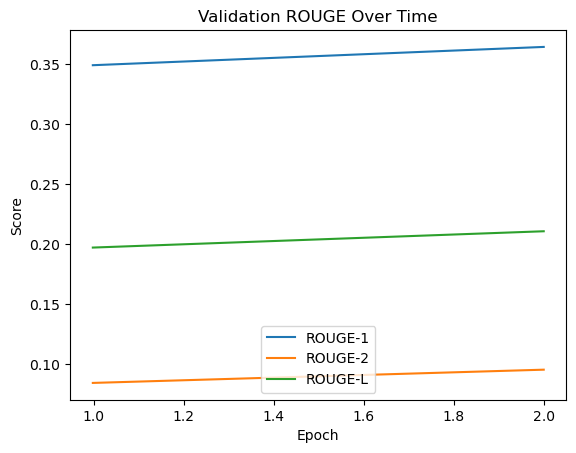

In [ ]:
plt.figure()

if "eval_rougeL" in df.columns:
    eval_rouge = df[df["eval_rougeL"].notna()]

    plt.plot(eval_rouge["epoch"], eval_rouge["eval_rouge1"], label="ROUGE-1")
    plt.plot(eval_rouge["epoch"], eval_rouge["eval_rouge2"], label="ROUGE-2")
    plt.plot(eval_rouge["epoch"], eval_rouge["eval_rougeL"], label="ROUGE-L")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation ROUGE Over Time")
plt.legend()
plt.show()

In [ ]:
meeting_logs = df[df["meeting_rougeL"].notna()]

plt.figure()

plt.plot(meeting_logs["epoch"], meeting_logs["meeting_rougeL"], label="Meeting ROUGE-L")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Meeting-Level ROUGE (True Performance)")
plt.legend()

plt.show()

KeyError: 'meeting_rougeL'